In [1]:
%load_ext autoreload
%autoreload 2   

import arviz as az
import numpy as np
import pandas as pd

from pyprojroot import here
import pymc as pm

import mmm_utils.plot as mmm_plot
import mmm_utils.post_modeling as mmm_post_plot
from mmm_utils import Timeline
from mmm_utils.data_logger import data_logger

from mmm_pipeline import (
    load_env_variables,
    load_checked_data,
    fit_media_mix_model,
    make_report_files,
)

run_id = "0"
data_logger.change_dir(here() / "logs" / run_id)
config = load_env_variables()


/home/acaillebotte/projects/MMM/mmm_pipeline/mmm_pipeline/pipeline_steps/results.py:36: UserWarning: You appear to be connected to a CosmosDB cluster. For more information regarding feature compatibility and support please visit https://www.mongodb.com/supportability/cosmosdb
  client = MongoClient(uri)
/home/acaillebotte/projects/MMM/jardiland/.venv/lib/python3.12/site-packages/pymongo/synchronous/mongo_client.py:1776: UserWarning: You appear to be connected to a CosmosDB cluster. For more information regarding feature compatibility and support please visit https://www.mongodb.com/supportability/cosmosdb
  self._resolve_srv()


## Loading the data and plotting spend and sales

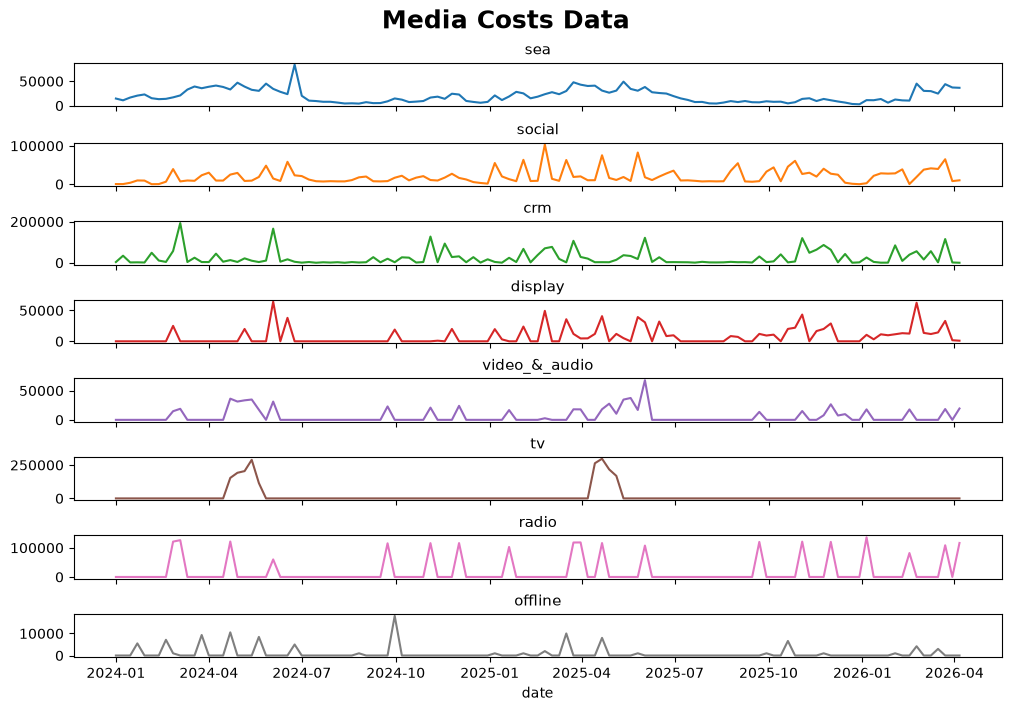

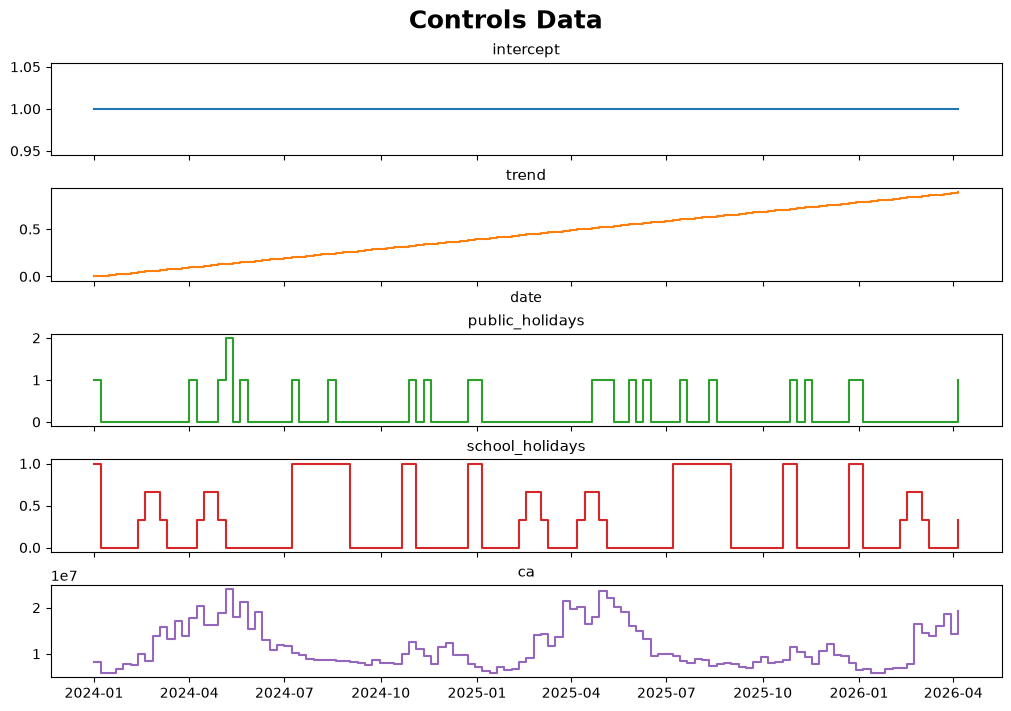

In [2]:
loaded_data = load_checked_data(run_id, config.data)

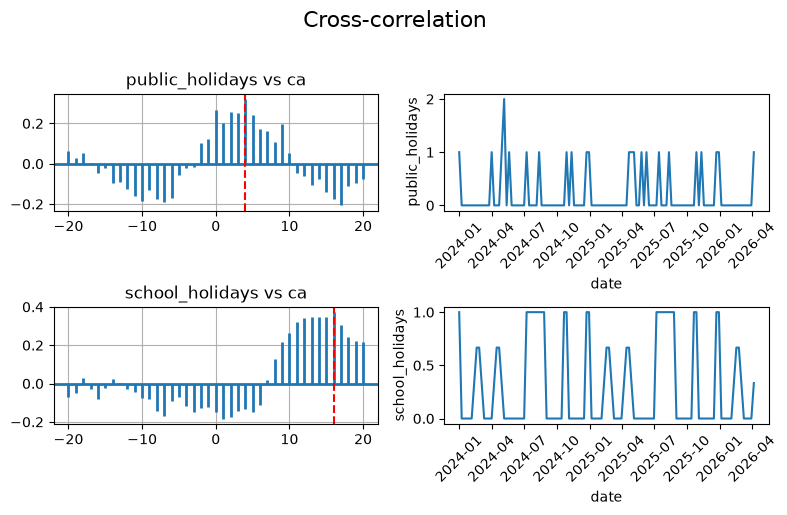

In [3]:
_, axes = mmm_plot.plot_cross_correlation(
    loaded_data.data, media=[], controls=loaded_data.controls[2:], target="ca"
)

_ = axes[0, 0].axvline(x=4, color="red", linestyle="--")
_ = axes[1, 0].axvline(x=16, color="red", linestyle="--")
# _ = axes[2, 0].axvline(x=12, color="red", linestyle="--")

In [4]:
mmm_plot.corr_plot(
    loaded_data.data, media=[], controls=loaded_data.controls, target="ca"
)


/home/acaillebotte/projects/MMM/jardiland/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/home/acaillebotte/projects/MMM/jardiland/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,intercept,trend,public_holidays,school_holidays,ca
intercept,nan,nan,nan,nan,nan
trend,nan,1.00,-0.03,-0.02,-0.11
public_holidays,nan,-0.03,1.00,0.27,0.27
school_holidays,nan,-0.02,0.27,1.00,-0.15
ca,nan,-0.11,0.27,-0.15,1.00


In [5]:
# data["school_holidays"] = data["school_holidays"].shift(4, fill_value=0)
# data["public_holidays"] = data["public_holidays"].shift(16, fill_value=0)
# # data["temperature"] = data["temperature"].shift(-12, fill_value=0)

# y = y[:-11]
# X = X[:-11]
# data = pd.concat([X, y], axis=1)

# mmm_plot.corr_plot(pd.concat([X, y], axis=1), media=[], controls=controls, target="ca")

## Modeling

In [6]:
from model_definition import get_builded_model


fit_result = fit_media_mix_model(
    run_id,
    get_builded_model,
    loaded_data,
    config.pymc,
)

Priors that need to be defined :
{'l_max': np.int64(8), 'normalize': False, 'alpha': XTensorConstant(XTensorType(float64, shape=(5,), dims=('media_agrp0',)), data=array([0.2 ... 5 , 0.5 ]))}
{'l_max': np.int64(8), 'normalize': False, 'alpha': adstock_alpha_agrp1}


/home/acaillebotte/projects/MMM/mmm_utils/mmm_utils/modeling/mmm.py:202: UserWarning: Channels ['social', 'crm', 'tv'] have different l_max values [np.int64(8), np.int64(8), np.int64(26)]. Using l_max=26 (maximum) for all channels in this adstock group.
  x_transformed = handler.apply(x_m)
NUTS[numpyro]: [beta_media, beta_control, beta_season, adstock_alpha_agrp1, saturation_lam_sgrp0, saturation_k[video_&_audio], saturation_n[video_&_audio], sigma]
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


  0%|          | 0/3200 [00:00<?, ?it/s]

  0%|          | 0/3200 [00:00<?, ?it/s]

  0%|          | 0/3200 [00:00<?, ?it/s]

...

Output()

/home/acaillebotte/projects/MMM/jardiland/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [adstock_alpha_agrp1, beta_control, beta_media, beta_season, saturation_k[video_&_audio], saturation_lam_sgrp0, saturation_n[video_&_audio], sigma, y]


Output()

/home/acaillebotte/projects/MMM/jardiland/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: []
/home/acaillebotte/projects/MMM/jardiland/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: []
/home/acaillebotte/projects/MMM/jardiland/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: []
/home/acaillebotte/projects/MMM/jardi

	 Starting Optimization
✅ Budget template created :
	<xarray.DataArray (date: 1, media: 8)> Size: 64B
array([[0.23618556, 0.19480787, 0.1232374 , 0.12274365, 0.08770379,
        0.05372357, 0.13249012, 0.0493282 ]])
Coordinates:
  * date     (date) datetime64[us] 8B 2026-04-13
  * media    (media) <U13 416B 'sea' 'social' 'crm' ... 'tv' 'radio' 'offline'
✅ Replacing RVs with posterior samples in the graph:
	 * beta_media 	 with constant beta_media{[[0.158222 ... 15909523]]}
	 * adstock_alpha_agrp1 	 with constant adstock_alpha_agrp1{[[0.258961 ... 83245478]]}
	 * saturation_lam_sgrp0 	 with constant saturation_lam_sgrp0{[[1.158619 ... 42126122]]}
	 * saturation_n[video_&_audio] 	 with constant saturation_n[video_&_audio]{[0.9152029 ... .40250981]}
	 * saturation_k[video_&_audio] 	 with constant saturation_k[video_&_audio]{[0.2616248 ... .56129454]}

⌛Budget 1.0002, Remaining Budget -1.17e-13, Objective -1.66e-01, 
⌛Budget 1.0002, Remaining Budget -1.17e-13, Objective -1.66e-01, 
Budget

In [7]:
# pm.model_to_graphviz(model=fit_result.mmm.model)

In [8]:
from mmm_pipeline import check_convergence

check_cv_results = check_convergence(run_id, fit_result)
check_cv_results

ConvergenceCheckResult(	max_rhat=1.0, 
	rhat_ok=True, ✅ 
	min_ess_bulk=2847.0, 
	min_ess_tail=2634.0, 
	ess_ok=True, ✅ 
	ess_rate_bulk=0.593125, 
	ess_rate_tail=0.54875, 
	ess_rate_warn=False, 
	n_divergences=0, 
	divergence_rate=0.0, 
	divergences_ok=True, ✅ 
	min_bfmi=0.8078161409612737, 
	bfmi_ok=True, ✅
)

In [10]:
from mmm_pipeline import check_model_viability

viability_results = check_model_viability(fit_result)
viability_results

ModelViabilityResult(	elpd_loo=137.43281873057765,
	se_loo=7.485099624474355,
	p_loo=13.182122132244182,
	loo_pareto_k_warning=False,
	r2=0.79,
	comparison_available=False,
	elpd_delta=None,
	loo_ok=True,✅ 
	r2_delta=None,
	r2_ok=True,✅ 
	max_coef_shift_sd=None,
	max_shift_param=None,
	coef_stability_ok=True,✅
)

In [ ]:
make_report_files(run_id, fit_result, loaded_data)


In [ ]:
az.residual_r2(fit_result.mmm.idata, "y", group="posterior_predictive")

## ROPE analysis & Estimation printing

In [ ]:
# mmm_post_plot.robustness_check(estim, "Fragile")

In [ ]:
# signal_std = np.std(y_true)
# noise_std = estim.loc[estim["parameter"] == "sigma", "mean"].values[0]
# snr = signal_std / noise_std

# print(f"Signal std: {signal_std:.4f}")
# print(f"Noise std (sigma): {noise_std:.4f}")
# print(f"Signal-to-Noise Ratio (SNR): {snr:.2f}")

In [ ]:
from mmm_pipeline.le_lab_db import LeLabDataBase

db = LeLabDataBase(config.database)

db.list_documents("MMM_JARDILAND")